# Student Performance Prediction — Exploratory Data Analysis

## Objective
Explore and understand the student performance dataset before building the
machine learning pipeline.

The analysis focuses on:
- Dataset structure and data quality
- Missing values and duplicates
- Numerical and categorical features
- Feature distributions and outliers
- Relationships between features
- Relationship between input features and the target variable (`math_score`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/stud.csv")

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1000, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.columns.tolist()

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course',
 'math_score',
 'reading_score',
 'writing_score']

In [6]:
missing_values = df.isnull().sum()

missing_values

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary

,Missing Values,Percentage
gender,0,0.0
race_ethnicity,0,0.0
parental_level_of_education,0,0.0
lunch,0,0.0
test_preparation_course,0,0.0
math_score,0,0.0
reading_score,0,0.0
writing_score,0,0.0


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['math_score', 'reading_score', 'writing_score']

Categorical columns:
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [10]:
df[numerical_columns].describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


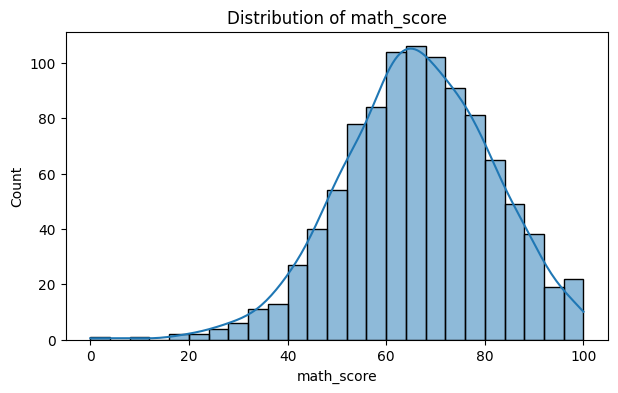

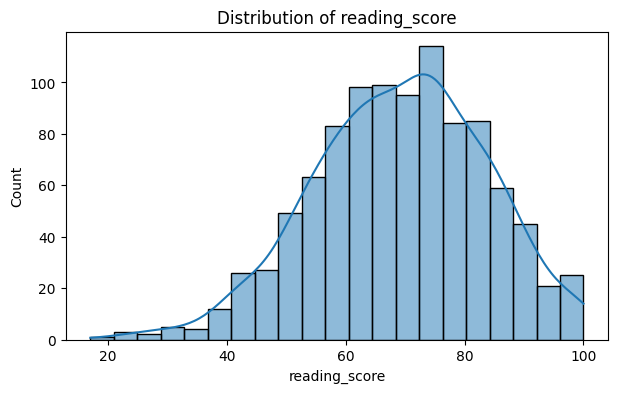

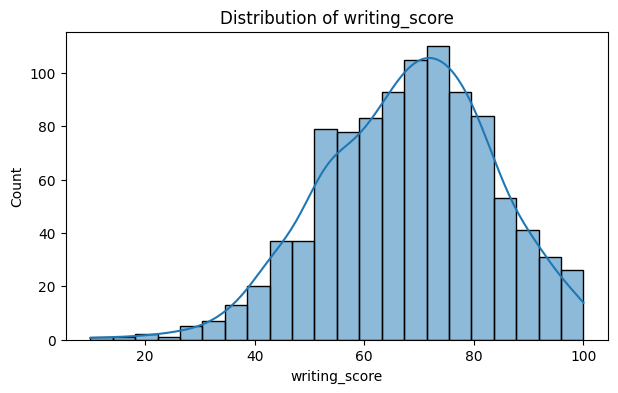

In [11]:
for column in numerical_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

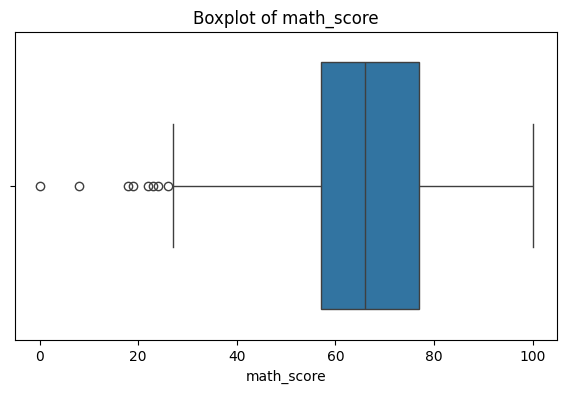

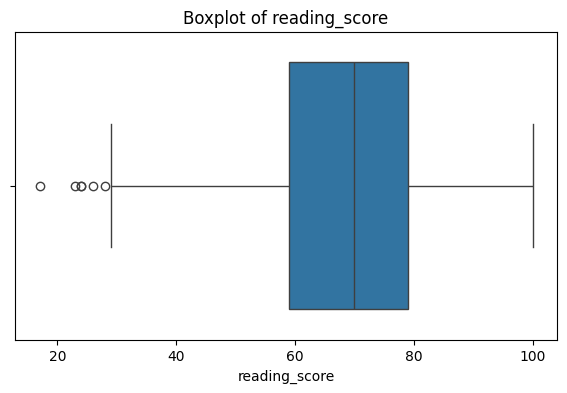

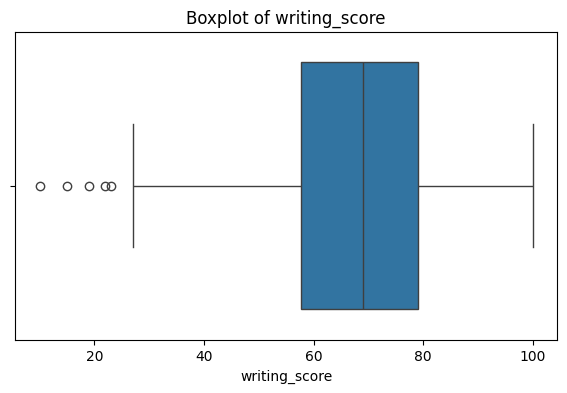

In [12]:
for column in numerical_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [13]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


gender
gender
female    518
male      482
Name: count, dtype: int64

race_ethnicity
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

parental_level_of_education
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

test_preparation_course
test_preparation_course
none         642
completed    358
Name: count, dtype: int64


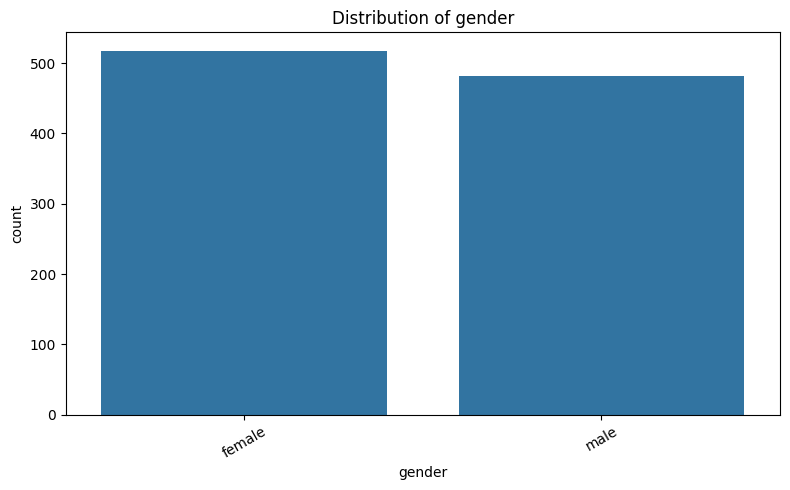

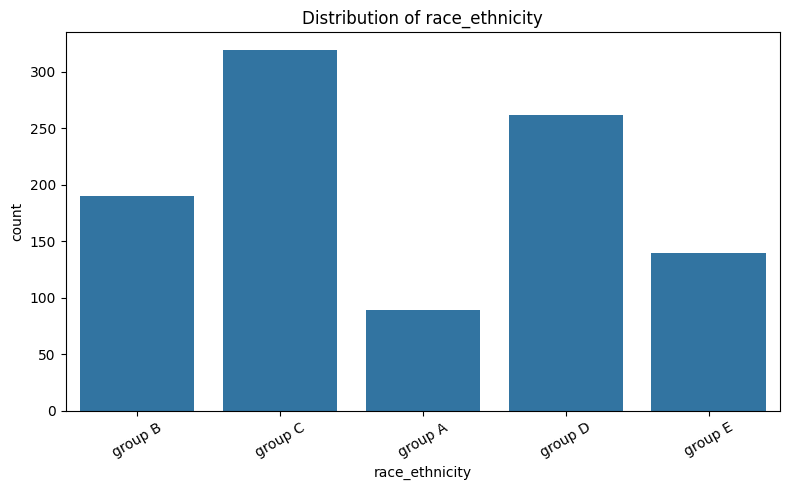

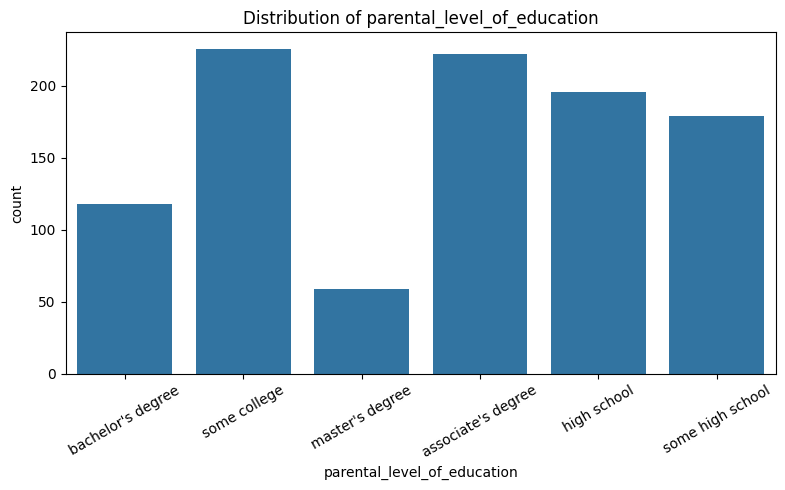

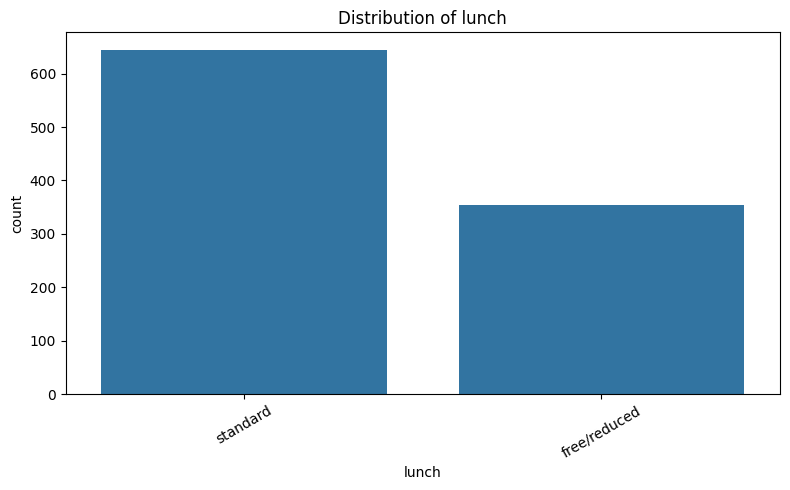

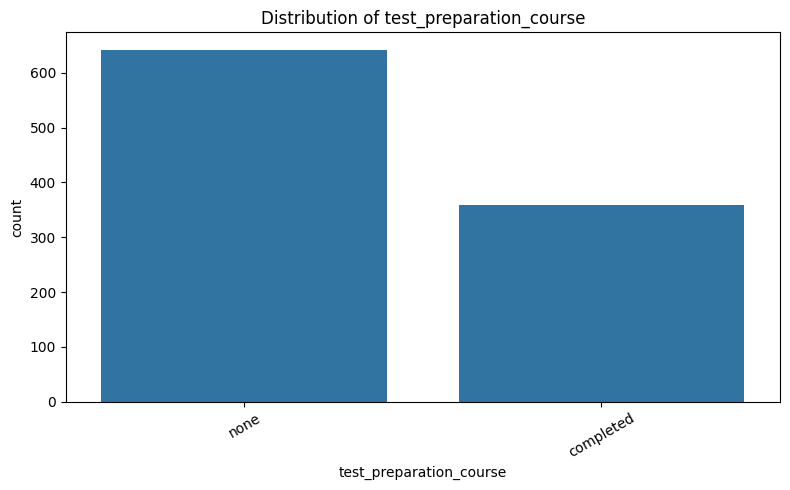

In [14]:
for column in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [15]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


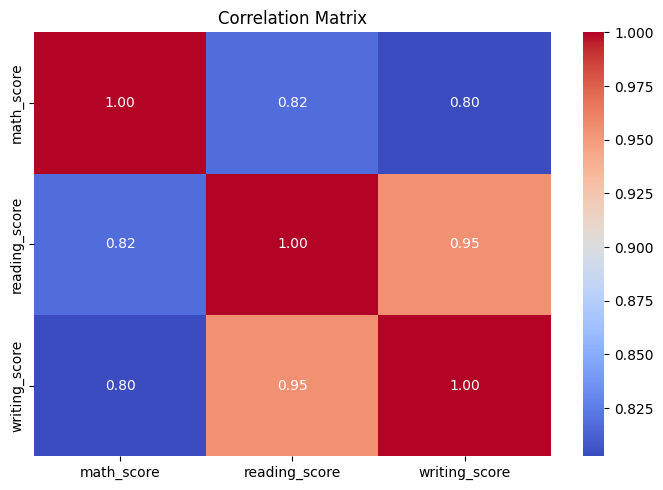

In [16]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

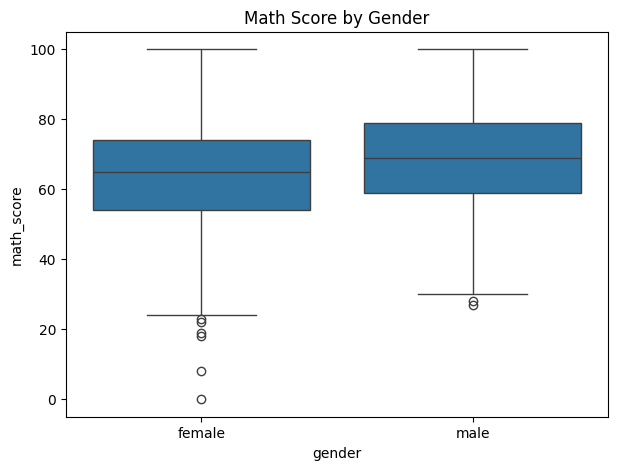

In [17]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="gender",
    y="math_score"
)

plt.title("Math Score by Gender")
plt.show()

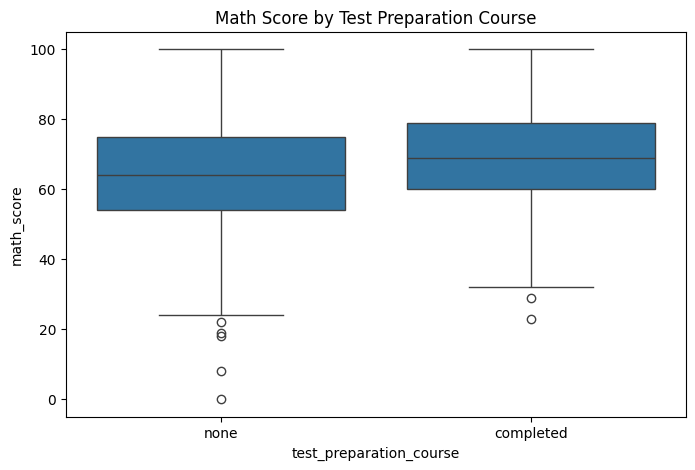

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="test_preparation_course",
    y="math_score"
)

plt.title("Math Score by Test Preparation Course")
plt.show()

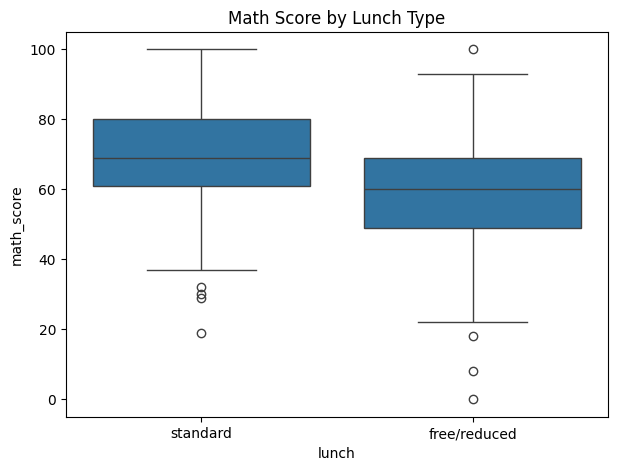

In [19]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="lunch",
    y="math_score"
)

plt.title("Math Score by Lunch Type")
plt.show()

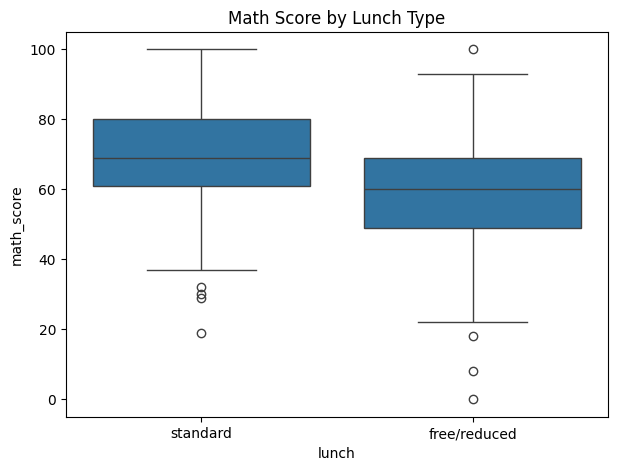

In [20]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="lunch",
    y="math_score"
)

plt.title("Math Score by Lunch Type")
plt.show()

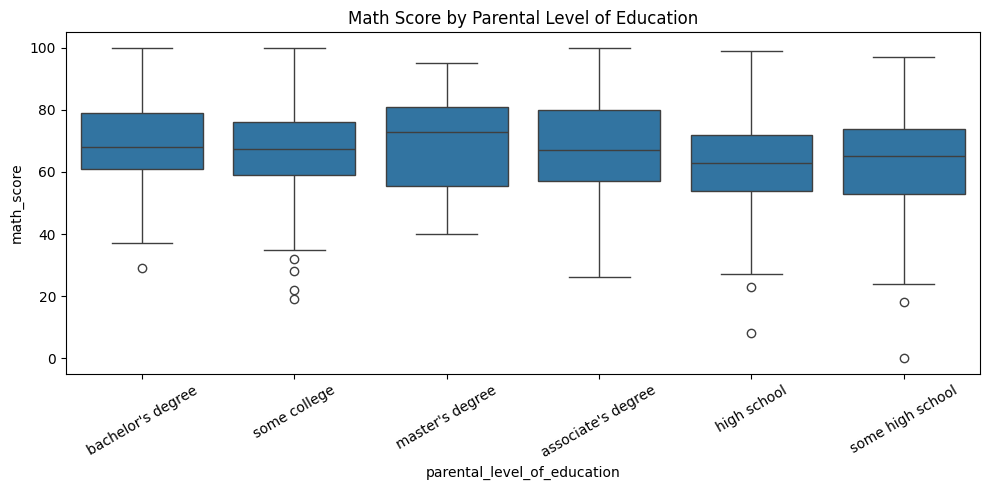

In [21]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="parental_level_of_education",
    y="math_score"
)

plt.title("Math Score by Parental Level of Education")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [22]:
for column in categorical_columns:
    print(f"\nAverage Math Score by {column}:")
    print(
        df.groupby(column)["math_score"]
        .mean()
        .sort_values(ascending=False)
    )


Average Math Score by gender:
gender
male      68.728216
female    63.633205
Name: math_score, dtype: float64

Average Math Score by race_ethnicity:
race_ethnicity
group E    73.821429
group D    67.362595
group C    64.463950
group B    63.452632
group A    61.629213
Name: math_score, dtype: float64

Average Math Score by parental_level_of_education:
parental_level_of_education
master's degree       69.745763
bachelor's degree     69.389831
associate's degree    67.882883
some college          67.128319
some high school      63.497207
high school           62.137755
Name: math_score, dtype: float64

Average Math Score by lunch:
lunch
standard        70.034109
free/reduced    58.921127
Name: math_score, dtype: float64

Average Math Score by test_preparation_course:
test_preparation_course
completed    69.695531
none         64.077882
Name: math_score, dtype: float64


In [23]:
print("Target variable: math_score")

print("\nTarget statistics:")
print(df["math_score"].describe())

Target variable: math_score

Target statistics:
count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math_score, dtype: float64


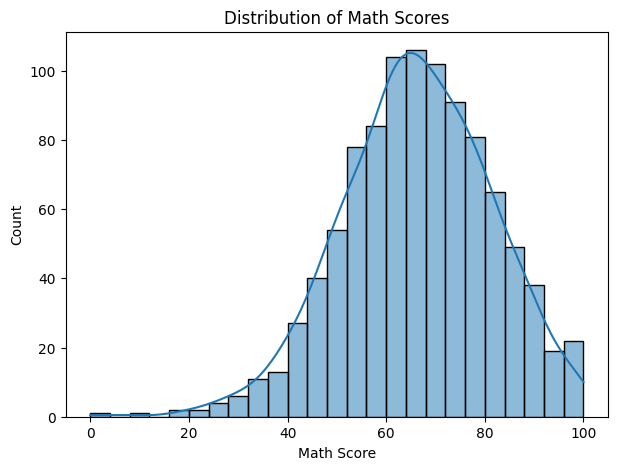

In [24]:
plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="math_score",
    kde=True
)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()

In [25]:
score_columns = [
    "math_score",
    "reading_score",
    "writing_score"
]

for column in score_columns:
    print(
        f"{column}: "
        f"min={df[column].min()}, "
        f"max={df[column].max()}"
    )

math_score: min=0, max=100
reading_score: min=17, max=100
writing_score: min=10, max=100


In [26]:
for column in score_columns:
    invalid = df[
        (df[column] < 0) |
        (df[column] > 100)
    ]

    print(f"{column}: {len(invalid)} invalid records")

math_score: 0 invalid records
reading_score: 0 invalid records
writing_score: 0 invalid records
